In [14]:
import pandas as pd
import time
import statsmodels.formula.api as smf
import numpy as np
import sys
sys.path.append("..")  # db_config.py lives in the repo root
from db_config import read_sql


# Configuration
pd.options.display.float_format = "{:,.2f}".format

TRAIN_END = "2019-12-01"
OUTCOME = "dlq90"#Either dlq30 or dlq90
LAGS ={"dlq30":4, "dlq90":5}
LAG_UR, LAG_HPI = LAGS[OUTCOME],7 
EXCLUDE = range(2005,2008)
VARS = ["ur_lag", "hpi_lag"]
LOG_FILE = "model_log.csv"
SHOCK_PRE, SHOCK_WINDOW = "2007-12-01", ("2008-01-01", "2010-12-01")
PERIODS = {"Covid mid (2020-2021)": ("2020-01-01", "2021-06-01"), "Mid 2022 on": ("2022-07-01", None)}
UNIFORM_SHOCK = 4.5
SCENARIO = "Uniform"


econ = read_sql(""" SELECT report_date, state, unemployment_rate, hpi_index FROM economic_indicators WHERE report_date >= '2002-01-01'""", parse_dates=["report_date"])
print(econ.shape, econ["state"].nunique())

(15096, 4) 51


In [15]:
#Gets grouped data quickly from set table
risk = read_sql("SELECT * FROM sf_state_month_risk")
risk["report_date"] = pd.to_datetime(risk["reporting_date"])


#Set FICO and LTV bands
fico_band = {"<640": "<680", "640-679": "<680", "680-739": "680-739", "740+": "740+"}
ltv_band = {"<=80": "<=90", "80-90": "<=90", "90-95": ">90", "95+": ">90"}

risk["tier"] = risk["fico_bucket"].map(fico_band) + " / " + risk["ltv_bucket"].map(ltv_band)

#Find Non-Used Loans
unmapped = risk[risk["tier"].isna()]
risk = risk[~risk["orig_year"].isin(EXCLUDE)]

check = risk.groupby("tier")[["loan_count", OUTCOME]].sum()
check["dlq_rate"] = check[OUTCOME] / check["loan_count"] * 100
print(check.round(3))


pt = (risk.groupby(["property_state", "tier", "report_date"], as_index=False)
          [["loan_count", "dlq30", "dlq90"]].sum())

pt = (pt.merge(econ, left_on=["property_state", "report_date"],
               right_on=["state", "report_date"], how="inner")
        .sort_values(["property_state", "tier", "report_date"]))

gaps = (pt.groupby(["property_state", "tier"]) ["report_date"]
        .apply(lambda s: (s.diff().dt.days>31).sum()))

bad = gaps[gaps > 0].index
pt = pt.set_index(["property_state", "tier"]).drop(bad).reset_index()
print(f"Series with gaps: {(gaps > 0).sum()} of {len(gaps)}")

grp = lambda c: pt.groupby(["property_state", "tier"])[c]
pt["dlq_rate"] = pt[OUTCOME] / pt["loan_count"] * 100
pt["dlq_chg"] = grp("dlq_rate").diff(12)
pt["ur_chg"] = grp("unemployment_rate").diff(12)
pt["ur_lag"] = grp("ur_chg").shift(LAG_UR)





                loan_count   dlq90  dlq_rate
tier                                        
680-739 / <=90    28943788  430667      1.49
680-739 / >90      4310805  133639      3.10
740+ / <=90       68968773  262339      0.38
740+ / >90         6001288   69581      1.16
<680 / <=90       17121655  636070      3.71
<680 / >90         2180342  133986      6.14
Series with gaps: 8 of 306


In [16]:
tr = pt[pt["report_date"] <= TRAIN_END].dropna(subset=["dlq_chg", "ur_lag"])

tiered = smf.wls("dlq_chg ~ C(tier) + ur_lag:C(tier)", data=tr,
                 weights=tr["loan_count"]).fit(
    cov_type="cluster", cov_kwds={"groups": tr["property_state"]})

betas = tiered.params.filter(like="ur_lag")
ses = tiered.bse.filter(like="ur_lag")

tier_beta = betas.copy()
tier_beta.index = tier_beta.index.str.extract(r"\[T?\.?(.+)\]")[0].values
ses.index = tier_beta.index


flat = smf.wls("dlq_chg ~ ur_lag", data=tr, weights=tr["loan_count"]).fit(
    cov_type="cluster", cov_kwds={"groups": tr["property_state"]})
flat_beta = flat.params["ur_lag"]

mix = check["loan_count"]/check["loan_count"].sum()

print(pd.DataFrame({"beta": tier_beta, "se": ses, "fannie_mix": mix}).round(3))



                beta   se  fannie_mix
680-739 / <=90  0.36 0.03        0.23
680-739 / >90   0.80 0.07        0.03
740+ / <=90     0.14 0.02        0.54
740+ / >90      0.42 0.04        0.05
<680 / <=90     0.74 0.05        0.13
<680 / >90      1.16 0.10        0.02


Covid mid (2020-2021): model RMSE 1.386 | naive RMSE 2.251
Mid 2022 on: model RMSE 0.364 | naive RMSE 0.611
Covid mid (2020-2021): intercept-only RMSE 2.291
Mid 2022 on: intercept-only RMSE 0.582


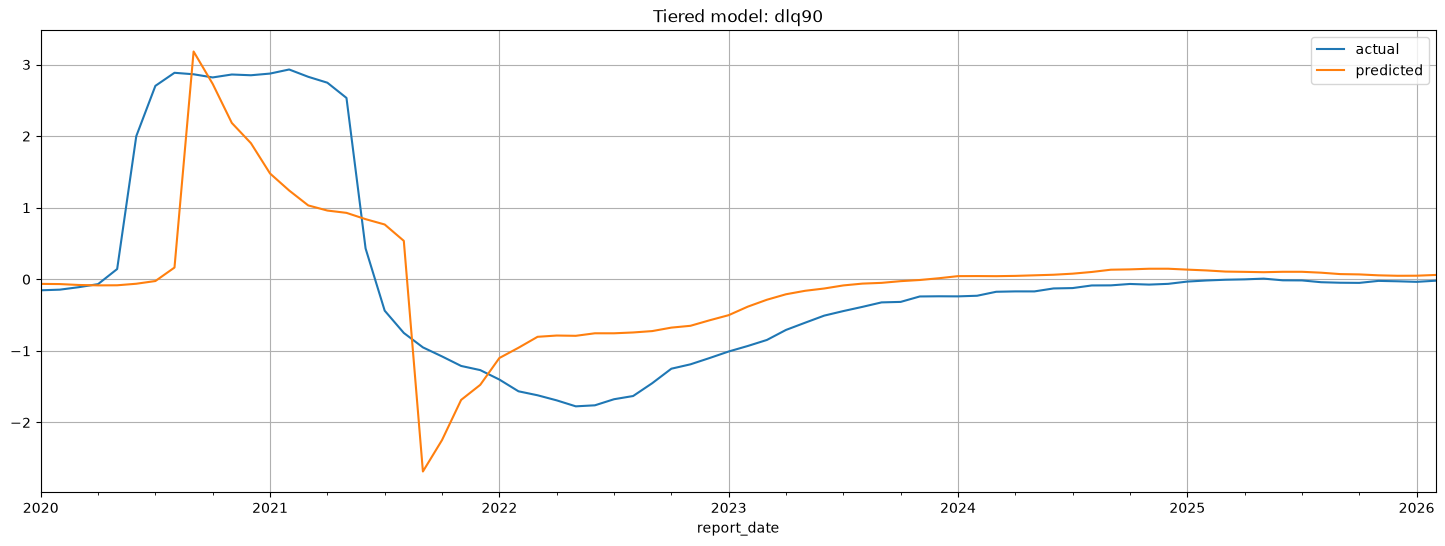

In [17]:
test = pt[pt["report_date"] > TRAIN_END].dropna(
    subset=["dlq_chg", "ur_lag"]).copy()


test["pred"] = tiered.predict(test)

test["w_actual"] = test["dlq_chg"] * test["loan_count"]
test["w_predicted"] = test["pred"] * test["loan_count"]

cmp = test.groupby("report_date")[["w_actual", "w_predicted", "loan_count"]].sum()
cmp["actual"] = cmp["w_actual"]/cmp["loan_count"]
cmp["predicted"] = cmp["w_predicted"]/cmp["loan_count"]

cmp[["actual", "predicted"]].plot(figsize=(18,6), grid=True, title=f"Tiered model: {OUTCOME}")

for name, (start, end) in PERIODS.items():
    p = cmp.loc[start:end]
    model_rmse = np.sqrt(((p["predicted"] - p["actual"]) ** 2).mean())
    naive_rmse = np.sqrt((p["actual"] ** 2).mean())
    print(f"{name}: model RMSE {model_rmse:.3f} | naive RMSE {naive_rmse:.3f}")

     
base = smf.wls("dlq_chg ~ C(tier)", data=tr, weights=tr["loan_count"]).fit()
test["pred_base"] = base.predict(test)
test["w_base"] = test["pred_base"] * test["loan_count"]
cmp["base"] = test.groupby("report_date")["w_base"].sum() / cmp["loan_count"]

for name, (start, end) in PERIODS.items():
    p = cmp.loc[start:end]
    base_rmse = np.sqrt(((p["base"] - p["actual"]) ** 2).mean())
    print(f"{name}: intercept-only RMSE {base_rmse:.3f}")



In [18]:
book = read_sql("""SELECT state_code
        , COUNT(*) AS Loans
        , SUM(unpaid_principal_balance) as unpaid_principal_balance
        , tier
        FROM (
        SELECT t.state_code, t2.unpaid_principal_balance
        ,CASE WHEN TRY_CAST(t.credit_score AS FLOAT) IS NULL THEN 'unknown'
        WHEN TRY_CAST(t.credit_score AS FLOAT) < 680 THEN '<680'
        WHEN TRY_CAST(t.credit_score AS FLOAT) < 740 THEN '680-739'
        ELSE '740+' END
        + ' / ' +
        CASE WHEN TRY_CAST(t.ltv AS FLOAT) IS NULL THEN 'unknown'
        WHEN TRY_CAST(t.ltv AS FLOAT) <= 90 THEN '<=90'
        ELSE '>90' END AS tier
        FROM mbs_loans_monthly t2
        JOIN gnma_static_table t ON t.disclosure_sequence_number = t2.disclosure_sequence_number
        WHERE t2.report_date = (SELECT MAX(report_date) FROM mbs_loans_monthly)
        ) x
        GROUP BY state_code, tier""")

book["state_code"] = book["state_code"].str.strip().str.upper()
book["tier"] = book["tier"].str.strip()
book["unpaid_principal_balance"] = book["unpaid_principal_balance"].astype(float)

book["beta"] = book["tier"].map(tier_beta)

mask = book["beta"].isna()
known = book[~mask]
ginnie_avg = (known["beta"] * known["unpaid_principal_balance"]).sum()/ known["unpaid_principal_balance"].sum()
book.loc[mask, "beta"] = ginnie_avg

print(f"Unknown credit details share of UPB {book.loc[mask, "unpaid_principal_balance"].sum()/book["unpaid_principal_balance"].sum():.1%}")
print(book.groupby("tier")["unpaid_principal_balance"].sum().div(1e9).round(1))

Unknown credit details share of UPB 9.8%
tier
680-739 / <=90      135.20
680-739 / >90       553.30
680-739 / unknown    12.90
740+ / <=90         175.10
740+ / >90          448.80
740+ / unknown       16.40
<680 / <=90         215.40
<680 / >90          735.40
<680 / unknown       12.10
unknown / <=90       56.60
unknown / >90       132.70
unknown / unknown    15.10
Name: unpaid_principal_balance, dtype: float64


In [19]:
if SCENARIO == "2008":
    pre = econ[econ['report_date'] == SHOCK_PRE].set_index("state")["unemployment_rate"] 
    peak = (econ[econ["report_date"].between(*SHOCK_WINDOW)]
        .groupby("state")["unemployment_rate"].max())
    scen = (peak-pre).rename("ur_shock").to_frame()
else:
    scen = pd.DataFrame({"ur_shock": UNIFORM_SHOCK}, index=econ["state"].unique())
    

stress = book.merge(scen, left_on="state_code", right_index=True, how="inner")
stress["stressed_upb"] = stress["beta"] * stress["ur_shock"] / 100 * stress["unpaid_principal_balance"]

total = stress["stressed_upb"].sum() / stress["unpaid_principal_balance"].sum() * 100
bucket = "90+" if OUTCOME == "dlq90" else "30+"
print(f"{SCENARIO} scenario, {OUTCOME}: +{total:.2f} pts book-wide, "
      f"${stress['stressed_upb'].sum()/1e9:.1f}B additional {bucket} delinquent UPB")



Uniform scenario, dlq90: +3.40 pts book-wide, $85.0B additional 90+ delinquent UPB


In [20]:
state_score = stress.groupby("state_code")[["unpaid_principal_balance", "stressed_upb"]].sum()
state_score["proj_dlq_chg"] = state_score["stressed_upb"] / state_score["unpaid_principal_balance"] * 100
state_score["upb_share"] = state_score["unpaid_principal_balance"] / state_score["unpaid_principal_balance"].sum() * 100
state_score["stress_share"] = state_score["stressed_upb"] / state_score["stressed_upb"].sum() * 100
state_score["conc_ratio"] = state_score["stress_share"] / state_score["upb_share"]
state_score["stressed_upb_bn"] = state_score["stressed_upb"] / 1e9

cols = ["upb_share", "proj_dlq_chg", "stressed_upb_bn", "stress_share", "conc_ratio"]


In [21]:
print(state_score.sort_values("stressed_upb_bn", ascending=False)[cols].head(10).round(2))

tier_beta.rename("beta_tier").to_csv(f"tier_betas_{OUTCOME}.csv", index_label="tier")
state_score[cols].to_csv(f"state_stress_{OUTCOME}_{SCENARIO}.csv")

state_score.sort_values("stressed_upb_bn", ascending=False)[cols].head(10).round(2).to_clipboard()


            upb_share  proj_dlq_chg  stressed_upb_bn  stress_share  conc_ratio
state_code                                                                    
TX              10.52          3.68             9.67         11.38        1.08
CA              10.36          3.18             8.22          9.68        0.93
FL               9.34          3.43             7.99          9.41        1.01
GA               4.29          3.54             3.79          4.46        1.04
VA               4.80          3.02             3.62          4.26        0.89
NC               3.57          3.31             2.95          3.47        0.97
MD               3.31          3.40             2.81          3.31        1.00
AZ               3.15          3.29             2.59          3.05        0.97
NY               2.76          3.50             2.41          2.84        1.03
IL               2.50          3.72             2.32          2.73        1.09
